In [5]:
import h5py
import numpy as np

# ÉTAPE 1 : Explorer la vraie structure du fichier
with h5py.File('../dataset/pems-bay.h5', 'r') as f:
    print("=== Structure complète du fichier ===")
    
    def afficher_structure(name, obj):
        indent = "  " * name.count('/')
        if isinstance(obj, h5py.Dataset):
            print(f"{indent}📊 DATASET : {name}  →  shape={obj.shape}  dtype={obj.dtype}")
        elif isinstance(obj, h5py.Group):
            print(f"{indent}📁 GROUP   : {name}")
    
    f.visititems(afficher_structure)

=== Structure complète du fichier ===
📁 GROUP   : speed
  📊 DATASET : speed/axis0  →  shape=(325,)  dtype=int64
  📊 DATASET : speed/axis1  →  shape=(52116,)  dtype=int64
  📊 DATASET : speed/block0_items  →  shape=(325,)  dtype=int64
  📊 DATASET : speed/block0_values  →  shape=(52116, 325)  dtype=float64


In [6]:
import pandas as pd

df = pd.read_hdf('../dataset/pems-bay.h5')
print(df.shape)    # attendu : (52116, 325)
print(df.head())

data = df.values   # convertir en numpy array
print(f"✅ data.shape = {data.shape}")

(52116, 325)
sensor_id            400001  400017  400030  400040  400045  400052  400057  \
2017-01-01 00:00:00    71.4    67.8    70.5    67.4    68.8    66.6    66.8   
2017-01-01 00:05:00    71.6    67.5    70.6    67.5    68.7    66.6    66.8   
2017-01-01 00:10:00    71.6    67.6    70.2    67.4    68.7    66.1    66.8   
2017-01-01 00:15:00    71.1    67.5    70.3    68.0    68.5    66.7    66.6   
2017-01-01 00:20:00    71.7    67.8    70.2    68.1    68.4    66.9    66.1   

sensor_id            400059  400065  400069  ...  409525  409526  409528  \
2017-01-01 00:00:00    68.0    66.8    69.0  ...    68.8    67.9    68.8   
2017-01-01 00:05:00    67.8    66.5    68.2  ...    68.4    67.3    68.4   
2017-01-01 00:10:00    67.8    66.2    67.8  ...    68.4    67.4    68.4   
2017-01-01 00:15:00    67.7    65.9    67.8  ...    68.5    67.5    68.5   
2017-01-01 00:20:00    67.7    66.1    67.8  ...    68.5    67.7    68.5   

sensor_id            409529  413026  413845  413877  41

In [7]:
# Créer un DataFrame pour faciliter l'analyse
df = pd.DataFrame(data)
print("📊 Statistiques générales :")
print(df.describe().round(2))

print(f"\n❌ Valeurs manquantes : {df.isnull().sum().sum()}")
print(f"⚡ Vitesse min : {df.min().min():.2f} km/h")
print(f"⚡ Vitesse max : {df.max().max():.2f} km/h")
print(f"⚡ Vitesse moyenne : {df.mean().mean():.2f} km/h")

📊 Statistiques générales :
            0         1         2         3         4         5         6    \
count  52116.00  52116.00  52116.00  52116.00  52116.00  52116.00  52116.00   
mean      67.57     59.02     59.14     62.14     61.20     63.31     58.78   
std        8.12     13.25     11.66      8.62     11.02     11.16     13.08   
min        0.00     11.00      3.40      0.00      7.40      0.00      0.00   
25%       67.30     62.20     55.80     59.40     57.50     65.00     58.40   
50%       70.30     64.00     62.70     66.20     63.50     66.50     63.70   
75%       71.30     65.10     66.60     67.70     69.50     67.50     66.30   
max       80.40     71.60     77.70     76.90     78.90     78.70     78.20   

            7         8         9    ...       315       316       317  \
count  52116.00  52116.00  52116.00  ...  52116.00  52116.00  52116.00   
mean      63.57     62.07     57.73  ...     65.80     63.62     63.82   
std        8.43     10.56     18.11  ..

C:\Users\HP\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\HP\AppData\Local\Temp\ipykernel_12116\1526364853.py:47: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('eda_trafic.png', dpi=150, bbox_inches='tight')
C:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


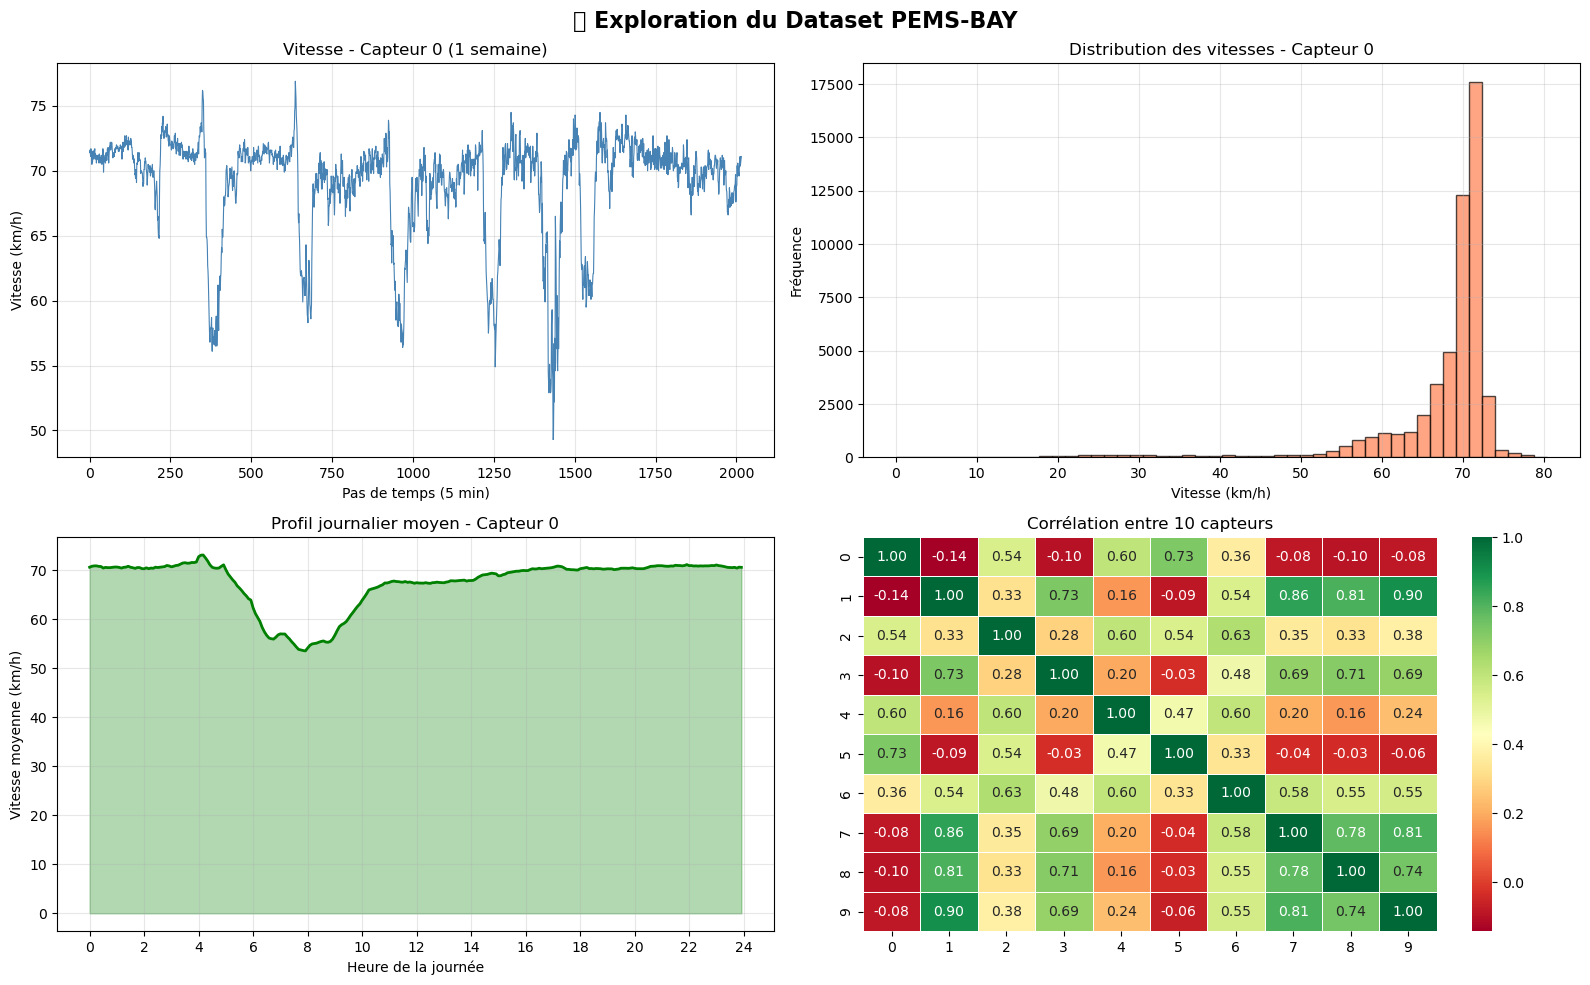

✅ Figure sauvegardée : eda_trafic.png


In [8]:
# Visualisation : 1 semaine du capteur 0
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
une_semaine = 7 * 24 * 12  # 7 jours × 24h × 12 pas/h

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('📈 Exploration du Dataset PEMS-BAY', fontsize=16, fontweight='bold')

# --- Plot 1 : Série temporelle 1 semaine ---
axes[0, 0].plot(df.iloc[:une_semaine, 0], color='steelblue', linewidth=0.8)
axes[0, 0].set_title('Vitesse - Capteur 0 (1 semaine)')
axes[0, 0].set_xlabel('Pas de temps (5 min)')
axes[0, 0].set_ylabel('Vitesse (km/h)')
axes[0, 0].grid(True, alpha=0.3)

# --- Plot 2 : Distribution des vitesses ---
axes[0, 1].hist(df.iloc[:, 0].dropna(), bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribution des vitesses - Capteur 0')
axes[0, 1].set_xlabel('Vitesse (km/h)')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].grid(True, alpha=0.3)

# --- Plot 3 : Profil journalier moyen ---
# Calculer la moyenne par heure de la journée
n_jours = len(df) // (24 * 12)
data_cap0 = df.iloc[:n_jours * 24 * 12, 0].values
data_reshape = data_cap0.reshape(n_jours, 24 * 12)
profil_journalier = data_reshape.mean(axis=0)
heures = np.arange(len(profil_journalier)) * 5 / 60  # en heures
axes[1, 0].plot(heures, profil_journalier, color='green', linewidth=2)
axes[1, 0].fill_between(heures, profil_journalier, alpha=0.3, color='green')
axes[1, 0].set_title('Profil journalier moyen - Capteur 0')
axes[1, 0].set_xlabel('Heure de la journée')
axes[1, 0].set_ylabel('Vitesse moyenne (km/h)')
axes[1, 0].set_xticks(range(0, 25, 2))
axes[1, 0].grid(True, alpha=0.3)

# --- Plot 4 : Heatmap corrélation entre 10 capteurs ---
corr = df.iloc[:, :10].corr()
sns.heatmap(corr, ax=axes[1, 1], cmap='RdYlGn', annot=True, fmt='.2f', 
            cbar=True, linewidths=0.5)
axes[1, 1].set_title('Corrélation entre 10 capteurs')

plt.tight_layout()
plt.savefig('eda_trafic.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : eda_trafic.png")

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ============================================================
# PARAMÈTRES GLOBAUX DU PROJET
# ============================================================
N_MOIS       = 1            # Utiliser 1 mois de données
N_PAS_ENTREE = 12           # Fenêtre d'entrée = 12 × 5 min = 1 heure
N_PAS_SORTIE = 3            # Prédire = 3 × 5 min = 15 minutes
CAPTEUR_ID   = 0            # Capteur utilisé pour ARIMA, SVM, CNN, LSTM
TRAIN_RATIO  = 0.80         # ← 80 % entraînement
# TEST = 20 % automatiquement
# ============================================================

# Sélectionner 1 mois de données
n_pas_mois = N_MOIS * 30 * 24 * 12  # ~8640 pas
data_mois  = data[:n_pas_mois]       # (8640, 325)

print(f"✅ Données sélectionnées : {data_mois.shape}")
print(f"   → {n_pas_mois} pas de temps = {N_MOIS} mois")
print(f"   → Fenêtre entrée  : {N_PAS_ENTREE} pas ({N_PAS_ENTREE * 5} min)")
print(f"   → Fenêtre sortie  : {N_PAS_SORTIE} pas ({N_PAS_SORTIE * 5} min)")
print(f"   → Split           : {int(TRAIN_RATIO*100)}% train / {int((1-TRAIN_RATIO)*100)}% test")

✅ Données sélectionnées : (8640, 325)
   → 8640 pas de temps = 1 mois
   → Fenêtre entrée  : 12 pas (60 min)
   → Fenêtre sortie  : 3 pas (15 min)
   → Split           : 80% train / 19% test


In [10]:
# ============================================================
# FONCTIONS UTILITAIRES
# ============================================================

def creer_sequences(serie, n_entree, n_sortie):
    """
    Transforme une série temporelle en paires (X, y).
    serie    : array 1D de forme (T,)
    n_entree : nombre de pas passés
    n_sortie : nombre de pas futurs à prédire
    """
    X, y = [], []
    for i in range(len(serie) - n_entree - n_sortie + 1):
        X.append(serie[i : i + n_entree])
        y.append(serie[i + n_entree : i + n_entree + n_sortie])
    return np.array(X), np.array(y)


def split_train_test(X, y, train_r=0.80):
    """Découpe les données en train (80%) / test (20%) — sans validation."""
    n       = len(X)
    n_train = int(n * train_r)

    X_train, y_train = X[:n_train],   y[:n_train]
    X_test,  y_test  = X[n_train:],   y[n_train:]

    print(f"   Train : {X_train.shape[0]} échantillons  ({int(train_r*100)}%)")
    print(f"   Test  : {X_test.shape[0]}  échantillons  ({int((1-train_r)*100)}%)")

    return X_train, y_train, X_test, y_test


def evaluer(y_true, y_pred, nom_modele, scaler=None):
    """Calcule et affiche MAE, RMSE, MAPE."""
    if scaler is not None:
        y_true = scaler.inverse_transform(y_true.reshape(-1, 1)).flatten()
        y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    print(f"\n📊 [{nom_modele}] Résultats sur le jeu de TEST (20%) :")
    print(f"   MAE  = {mae:.4f} km/h")
    print(f"   RMSE = {rmse:.4f} km/h")
    print(f"   MAPE = {mape:.2f} %")

    return {'modele': nom_modele, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}


# Dictionnaire pour stocker les résultats de tous les modèles
resultats_globaux = []

print("✅ Fonctions utilitaires définies  (split 80/20 sans validation)")

✅ Fonctions utilitaires définies  (split 80/20 sans validation)


In [11]:
# ============================================================
# PRÉPARATION POUR ARIMA / SVM / CNN / LSTM (1 capteur)
# ============================================================

# Extraire le capteur choisi
serie_brute = data_mois[:, CAPTEUR_ID]  # (8640,)

# Normalisation
scaler_1d  = StandardScaler()
serie_norm = scaler_1d.fit_transform(serie_brute.reshape(-1, 1)).flatten()

# Créer les séquences
X_1d, y_1d = creer_sequences(serie_norm, N_PAS_ENTREE, N_PAS_SORTIE)
print(f"Séquences créées : X={X_1d.shape}, y={y_1d.shape}")

# Split 80 / 20
print("\nSplit train / test (80 / 20) :")
X_train_1d, y_train_1d, X_test_1d, y_test_1d = \
    split_train_test(X_1d, y_1d, TRAIN_RATIO)

print(f"\n✅ Données 1D prêtes (capteur {CAPTEUR_ID})")

Séquences créées : X=(8626, 12), y=(8626, 3)

Split train / test (80 / 20) :
   Train : 6900 échantillons  (80%)
   Test  : 1726  échantillons  (19%)

✅ Données 1D prêtes (capteur 0)


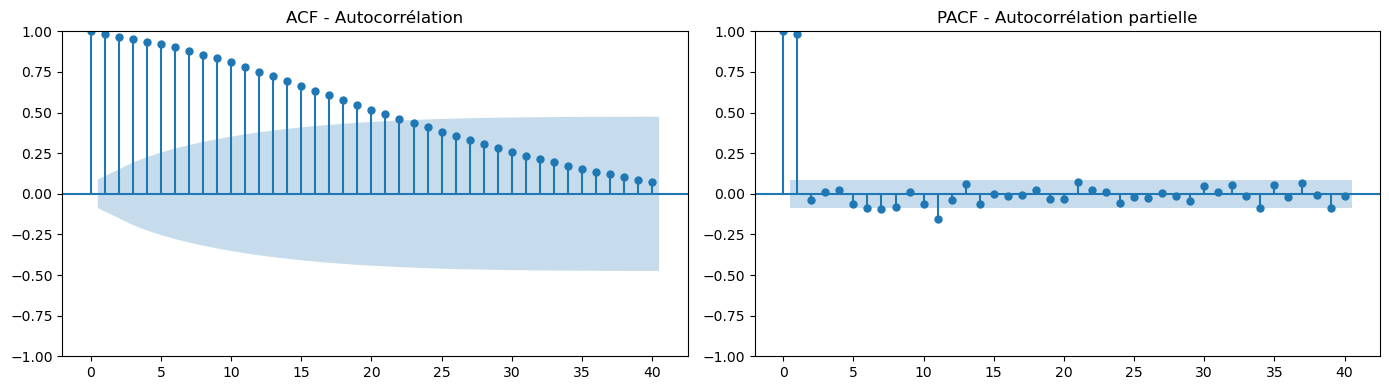

💡 Interprétation : p = lag où PACF coupe, q = lag où ACF coupe


In [12]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Analyse ACF/PACF pour choisir les paramètres p, d, q
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(serie_norm[:500], lags=40, ax=axes[0], title='ACF - Autocorrélation')
plot_pacf(serie_norm[:500], lags=40, ax=axes[1], title='PACF - Autocorrélation partielle')
plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Interprétation : p = lag où PACF coupe, q = lag où ACF coupe")

In [13]:
# ============================================================
# ARIMA - Entraînement et prédiction
# PARAMÈTRES ARIMA(p, d, q) :
#   p = ordre AR (regarder PACF)
#   d = ordre différenciation (souvent 1)
#   q = ordre MA (regarder ACF)
# ============================================================

# Données d'entraînement pour ARIMA (série brute, pas de séquences)
n_train_arima = int(len(serie_norm) * TRAIN_RATIO)
n_test_arima  = N_PAS_SORTIE * 50  # Prédire sur 50 fenêtres

serie_train_arima = serie_norm[:n_train_arima]
serie_test_arima  = serie_norm[n_train_arima : n_train_arima + N_PAS_ENTREE + n_test_arima]

print("🔄 Entraînement ARIMA en cours...")
print(f"   (Paramètres : p=2, d=1, q=2)")
print("   ⚠️  ARIMA est lent sur de grandes séries — patience !")

# Entraîner ARIMA
modele_arima = ARIMA(serie_train_arima, order=(2, 1, 2))
modele_arima_fit = modele_arima.fit()

print("\n✅ ARIMA entraîné")
print(modele_arima_fit.summary())

🔄 Entraînement ARIMA en cours...
   (Paramètres : p=2, d=1, q=2)
   ⚠️  ARIMA est lent sur de grandes séries — patience !

✅ ARIMA entraîné
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 6912
Model:                 ARIMA(2, 1, 2)   Log Likelihood                1751.889
Date:                Sun, 08 Mar 2026   AIC                          -3493.779
Time:                        15:29:42   BIC                          -3459.574
Sample:                             0   HQIC                         -3481.985
                               - 6912                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0185      0.041     24.577      0.000       0.937    

🔮 Prédiction sur 100 fenêtres...
   20/100 fenêtres traitées
   40/100 fenêtres traitées
   60/100 fenêtres traitées
   80/100 fenêtres traitées
   100/100 fenêtres traitées

📊 [ARIMA] Résultats sur le jeu de TEST (20%) :
   MAE  = 2.5733 km/h
   RMSE = 4.6568 km/h
   MAPE = 5.08 %


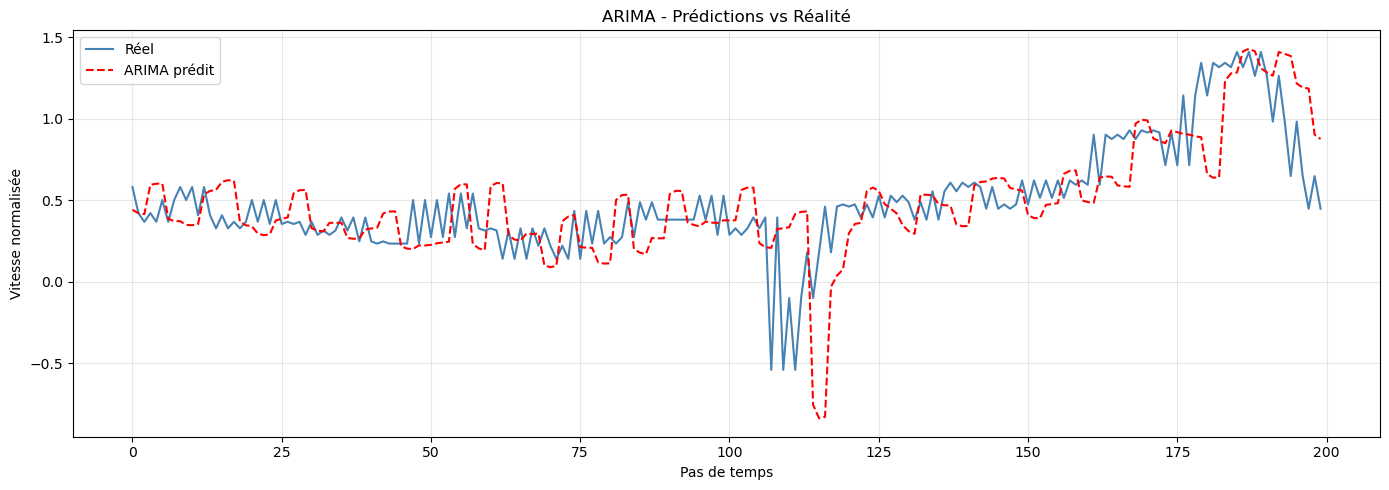

In [14]:
# Prédiction ARIMA - méthode rolling (fenêtre glissante)
historique = list(serie_train_arima)
predictions_arima = []
valeurs_reelles    = []

n_predictions = min(100, len(serie_test_arima) - N_PAS_SORTIE)
print(f"🔮 Prédiction sur {n_predictions} fenêtres...")

for i in range(n_predictions):
    # Réentraîner sur les données disponibles
    modele_temp = ARIMA(historique, order=(2, 1, 2))
    modele_temp_fit = modele_temp.fit()
    
    # Prédire les N_PAS_SORTIE prochains pas
    pred = modele_temp_fit.forecast(steps=N_PAS_SORTIE)
    predictions_arima.append(pred)
    
    # Vrai prochain pas
    vrai = serie_test_arima[i : i + N_PAS_SORTIE]
    valeurs_reelles.append(vrai)
    
    # Mettre à jour l'historique
    historique.append(serie_test_arima[i])
    
    if (i+1) % 20 == 0:
        print(f"   {i+1}/{n_predictions} fenêtres traitées")

predictions_arima = np.array(predictions_arima).flatten()
valeurs_reelles   = np.array(valeurs_reelles).flatten()

# Évaluation
res_arima = evaluer(valeurs_reelles, predictions_arima, 'ARIMA', scaler_1d)
resultats_globaux.append(res_arima)

# Visualisation
plt.figure(figsize=(14, 5))
n_show = min(200, len(valeurs_reelles))
plt.plot(valeurs_reelles[:n_show], label='Réel', color='steelblue', linewidth=1.5)
plt.plot(predictions_arima[:n_show], label='ARIMA prédit', color='red', 
         linestyle='--', linewidth=1.5)
plt.title('ARIMA - Prédictions vs Réalité')
plt.xlabel('Pas de temps')
plt.ylabel('Vitesse normalisée')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('arima_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ============================================================
# FILTRE DE KALMAN — Implémentation NumPy
# ============================================================
# Modèle d'état : vitesse à t+1 ≈ vitesse à t  (Random Walk)
#
#   Équation d'état    : x_t = F * x_{t-1} + bruit_processus
#   Équation de mesure : z_t = H * x_t     + bruit_mesure
#
# Paramètres :
#   F  : matrice de transition (ici = 1 → modèle vitesse constante)
#   H  : matrice d'observation (ici = 1 → on observe directement la vitesse)
#   Q  : covariance du bruit de processus (incertitude du modèle)
#   R  : covariance du bruit de mesure    (incertitude du capteur)
#   P  : covariance de l'erreur d'estimation (mise à jour à chaque pas)
# ============================================================

class FiltreKalman1D:
    """
    Filtre de Kalman unidimensionnel pour séries temporelles.
    
    Paramètres
    ----------
    F : float  — coefficient de transition (1.0 = modèle vitesse constante)
    H : float  — coefficient d'observation (1.0 = observation directe)
    Q : float  — variance du bruit processus  (à calibrer)
    R : float  — variance du bruit de mesure  (à calibrer)
    x0 : float — état initial
    P0 : float — covariance initiale
    """
    def __init__(self, F=1.0, H=1.0, Q=1e-4, R=0.1, x0=0.0, P0=1.0):
        self.F  = F
        self.H  = H
        self.Q  = Q
        self.R  = R
        self.x  = x0   # état estimé
        self.P  = P0   # covariance de l'erreur

    def predire(self):
        """Étape 1 : Prédiction a priori."""
        x_pred = self.F * self.x
        P_pred = self.F * self.P * self.F + self.Q
        return x_pred, P_pred

    def mettre_a_jour(self, z, x_pred, P_pred):
        """Étape 2 : Correction par la mesure z."""
        # Gain de Kalman : pondère entre prédiction et mesure
        K = P_pred * self.H / (self.H * P_pred * self.H + self.R)
        # Mise à jour de l'état
        self.x = x_pred + K * (z - self.H * x_pred)
        # Mise à jour de la covariance
        self.P = (1 - K * self.H) * P_pred
        return self.x, K

    def step(self, z):
        """Un pas complet : prédire puis corriger."""
        x_pred, P_pred = self.predire()
        x_new, K = self.mettre_a_jour(z, x_pred, P_pred)
        return x_new, x_pred  # état filtré, prédiction


def kalman_forecast_horizon(serie, n_entree, n_sortie, Q=1e-4, R=0.08):
    """
    Applique le Filtre de Kalman en mode fenêtre glissante.
    
    Pour chaque fenêtre d'entrée de n_entree pas :
      1. Initialiser le filtre sur les valeurs de la fenêtre
      2. Prédire les n_sortie prochains pas
    
    Retourne les prédictions et les valeurs réelles correspondantes.
    """
    predictions = []
    valeurs_reelles = []

    for i in range(len(serie) - n_entree - n_sortie + 1):
        fenetre = serie[i : i + n_entree]  # 1 heure de passé
        cible   = serie[i + n_entree : i + n_entree + n_sortie]  # 15 min à prédire

        # Initialiser le filtre sur la fenêtre d'entrée
        kf = FiltreKalman1D(Q=Q, R=R, x0=fenetre[0], P0=1.0)
        for z in fenetre:
            kf.step(z)  # absorber chaque observation

        # Prédire n_sortie pas en avant (sans nouvelles mesures)
        preds_horizon = []
        for _ in range(n_sortie):
            x_pred, _ = kf.predire()
            preds_horizon.append(x_pred)
            # En mode prédiction pure : on n'a pas de nouvelle mesure
            # On utilise la prédiction comme pseudo-observation
            kf.x = x_pred
            kf.P = kf.P + kf.Q  # propagation de l'incertitude

        predictions.append(preds_horizon)
        valeurs_reelles.append(cible.tolist())

    return np.array(predictions), np.array(valeurs_reelles)


print("✅ Filtre de Kalman défini")
print("   Paramètres :")
print("   - F=1.0  : modèle vitesse constante (Random Walk)")
print("   - H=1.0  : observation directe de la vitesse")
print("   - Q=1e-4 : faible bruit processus (série lisse)")
print("   - R=0.08 : bruit de mesure modéré (capteurs réels)")

✅ Filtre de Kalman défini
   Paramètres :
   - F=1.0  : modèle vitesse constante (Random Walk)
   - H=1.0  : observation directe de la vitesse
   - Q=1e-4 : faible bruit processus (série lisse)
   - R=0.08 : bruit de mesure modéré (capteurs réels)


🔧 Calibration des paramètres Q et R sur la validation...

✅ Meilleurs paramètres trouvés :
   Q = 0.005  |  R = 0.01
   MAE validation = 0.2066


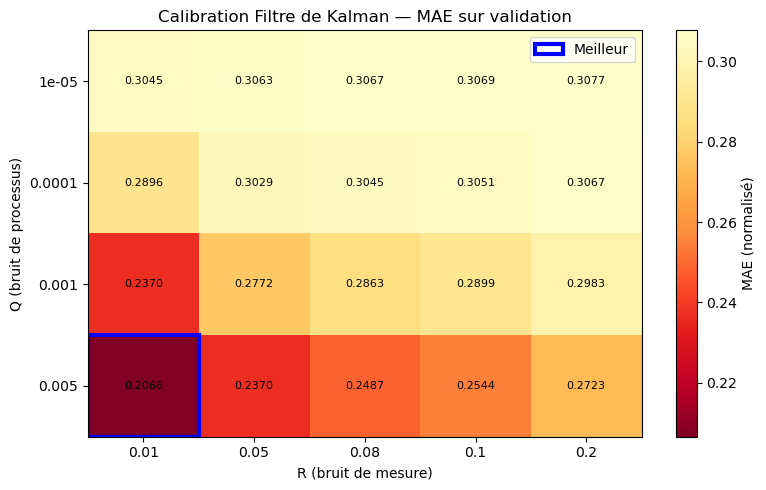

✅ Figure sauvegardée : kalman_calibration.png


In [16]:
# ============================================================
# CALIBRATION DES PARAMÈTRES Q ET R
# ============================================================
# On cherche les valeurs de Q et R qui minimisent le MAE
# sur le jeu de validation
# ============================================================

print("🔧 Calibration des paramètres Q et R sur la validation...")

# Reconstituer la série validation
# Utiliser 20% des données train pour la calibration Q/R
n_calib    = int(len(serie_norm) * 0.10)
n_train_k  = int(len(serie_norm) * TRAIN_RATIO)
serie_val_k = serie_norm[n_train_k - n_calib : n_train_k + N_PAS_ENTREE + N_PAS_SORTIE]

grille_Q = [1e-5, 1e-4, 1e-3, 5e-3]
grille_R = [0.01, 0.05, 0.08, 0.1, 0.2]

meilleur_mae  = np.inf
meilleur_Q    = 1e-4
meilleur_R    = 0.08
resultats_calib = []

for Q_val in grille_Q:
    for R_val in grille_R:
        preds_v, reels_v = kalman_forecast_horizon(
            serie_val_k, N_PAS_ENTREE, N_PAS_SORTIE, Q=Q_val, R=R_val
        )
        mae_v = mean_absolute_error(reels_v.flatten(), preds_v.flatten())
        resultats_calib.append((Q_val, R_val, mae_v))
        if mae_v < meilleur_mae:
            meilleur_mae = mae_v
            meilleur_Q   = Q_val
            meilleur_R   = R_val

print(f"\n✅ Meilleurs paramètres trouvés :")
print(f"   Q = {meilleur_Q}  |  R = {meilleur_R}")
print(f"   MAE validation = {meilleur_mae:.4f}")

# Visualisation de la grille de calibration
import itertools
calib_array = np.array(resultats_calib)
pivot = calib_array[:, 2].reshape(len(grille_Q), len(grille_R))

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot, cmap='YlOrRd_r', aspect='auto')
ax.set_xticks(range(len(grille_R)))
ax.set_yticks(range(len(grille_Q)))
ax.set_xticklabels([str(r) for r in grille_R])
ax.set_yticklabels([str(q) for q in grille_Q])
ax.set_xlabel('R (bruit de mesure)')
ax.set_ylabel('Q (bruit de processus)')
ax.set_title('Calibration Filtre de Kalman — MAE sur validation')
plt.colorbar(im, ax=ax, label='MAE (normalisé)')
for i in range(len(grille_Q)):
    for j in range(len(grille_R)):
        ax.text(j, i, f'{pivot[i,j]:.4f}', ha='center', va='center',
                fontsize=8, color='black')
# Marquer le meilleur
bi = grille_Q.index(meilleur_Q)
bj = grille_R.index(meilleur_R)
ax.add_patch(plt.Rectangle((bj-0.5, bi-0.5), 1, 1, fill=False,
                             edgecolor='blue', lw=3, label='Meilleur'))
ax.legend()
plt.tight_layout()
plt.savefig('kalman_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : kalman_calibration.png")

🔮 Prédiction Kalman sur le jeu de test...
   Q=0.005  R=0.01
   Prédictions shape : (1714, 3)
   Réelles shape     : (1714, 3)

📊 [Kalman] Résultats sur le jeu de TEST (20%) :
   MAE  = 1.3740 km/h
   RMSE = 2.7446 km/h
   MAPE = 2.38 %


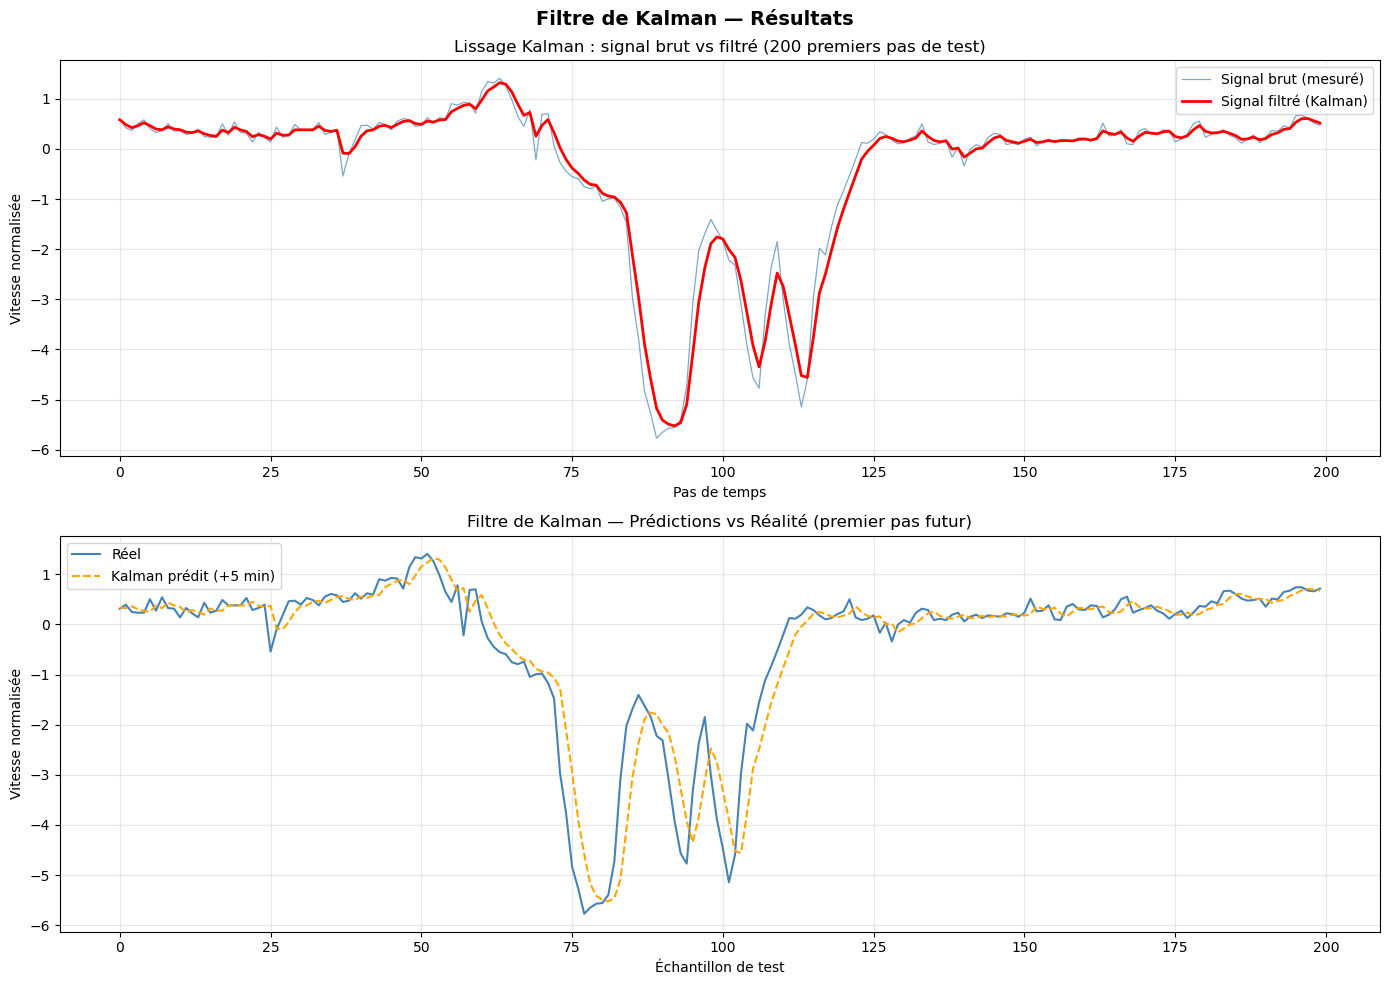

✅ Figure sauvegardée : kalman_predictions.png


In [17]:
# ============================================================
# FILTRE DE KALMAN — Prédiction sur le jeu de TEST
# ============================================================

print(f"🔮 Prédiction Kalman sur le jeu de test...")
print(f"   Q={meilleur_Q}  R={meilleur_R}")

# Série de test
n_train_k = int(len(serie_norm) * TRAIN_RATIO)
serie_test_k = serie_norm[n_train_k:]

predictions_kalman, valeurs_reelles_kalman = kalman_forecast_horizon(
    serie_test_k, N_PAS_ENTREE, N_PAS_SORTIE,
    Q=meilleur_Q, R=meilleur_R
)

print(f"   Prédictions shape : {predictions_kalman.shape}")
print(f"   Réelles shape     : {valeurs_reelles_kalman.shape}")

# Évaluation
res_kalman = evaluer(
    valeurs_reelles_kalman.flatten(),
    predictions_kalman.flatten(),
    'Kalman',
    scaler_1d
)
resultats_globaux.append(res_kalman)

# ── Visualisation : signal filtré vs brut sur la série de test ──
# Montrer aussi le lissage Kalman sur la série brute
serie_filtree = []
serie_brute_test = serie_test_k[:500]
kf_demo = FiltreKalman1D(Q=meilleur_Q, R=meilleur_R, x0=serie_brute_test[0])
for z in serie_brute_test:
    x_filtre, _ = kf_demo.step(z)
    serie_filtree.append(x_filtre)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Filtre de Kalman — Résultats', fontsize=14, fontweight='bold')

# Plot 1 : Signal filtré vs brut
axes[0].plot(serie_brute_test[:200], color='steelblue', lw=0.9,
             alpha=0.7, label='Signal brut (mesuré)')
axes[0].plot(serie_filtree[:200], color='red', lw=2.0,
             label='Signal filtré (Kalman)')
axes[0].set_title('Lissage Kalman : signal brut vs filtré (200 premiers pas de test)')
axes[0].set_xlabel('Pas de temps')
axes[0].set_ylabel('Vitesse normalisée')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 : Prédictions vs Réalité
n_show = min(200, len(valeurs_reelles_kalman))
axes[1].plot(valeurs_reelles_kalman[:n_show, 0], color='steelblue',
             lw=1.5, label='Réel')
axes[1].plot(predictions_kalman[:n_show, 0], color='orange',
             lw=1.5, ls='--', label='Kalman prédit (+5 min)')
axes[1].set_title('Filtre de Kalman — Prédictions vs Réalité (premier pas futur)')
axes[1].set_xlabel('Échantillon de test')
axes[1].set_ylabel('Vitesse normalisée')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kalman_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : kalman_predictions.png")

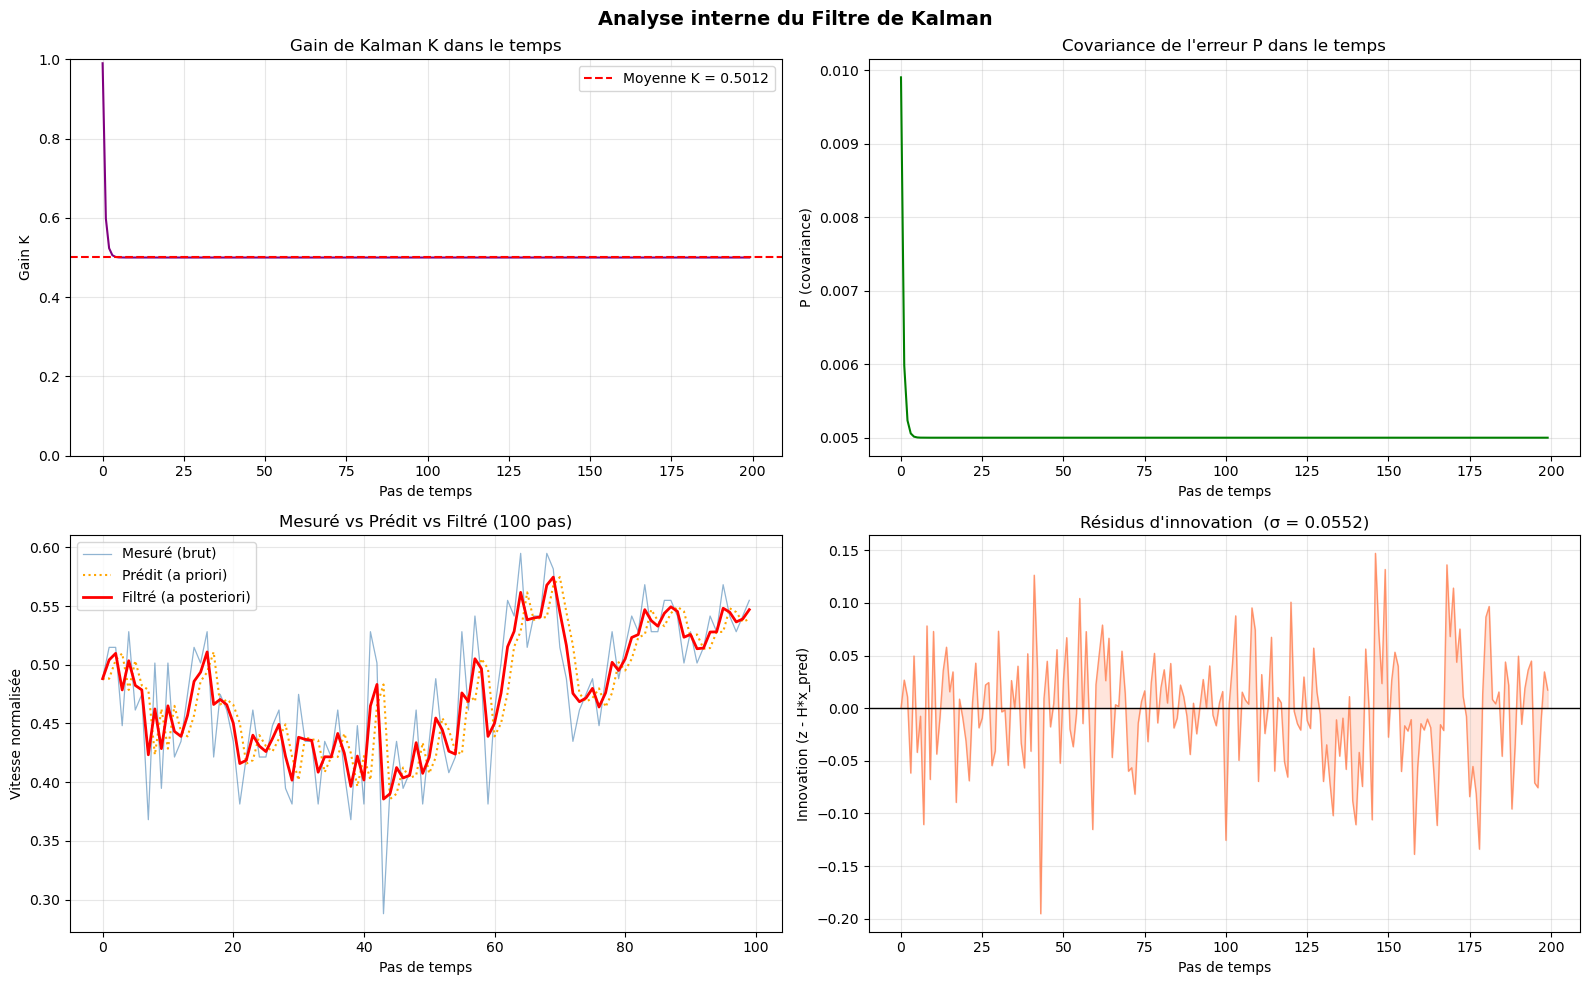

✅ Figure sauvegardée : kalman_analyse_interne.png


In [18]:
# ============================================================
# VISUALISATION DES GAINS DE KALMAN (analyse interne)
# ============================================================
# Le Gain de Kalman K indique comment le filtre pondère
# entre sa prédiction (modèle) et la mesure réelle :
#   K → 0 : confiance dans le modèle
#   K → 1 : confiance dans la mesure
# ============================================================

serie_demo = serie_norm[:500]
kf_demo2   = FiltreKalman1D(Q=meilleur_Q, R=meilleur_R, x0=serie_demo[0])

etats_filtres = []
etats_predits = []
gains_kalman  = []
covariances   = []

for z in serie_demo:
    x_pred, P_pred = kf_demo2.predire()
    K = P_pred * kf_demo2.H / (kf_demo2.H * P_pred * kf_demo2.H + kf_demo2.R)
    x_new, _ = kf_demo2.mettre_a_jour(z, x_pred, P_pred)
    etats_filtres.append(float(x_new))
    etats_predits.append(float(x_pred))
    gains_kalman.append(float(K))
    covariances.append(float(kf_demo2.P))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Analyse interne du Filtre de Kalman', fontsize=14, fontweight='bold')

# Gain de Kalman
axes[0, 0].plot(gains_kalman[:200], color='purple', lw=1.5)
axes[0, 0].axhline(np.mean(gains_kalman), color='red', ls='--',
                   label=f'Moyenne K = {np.mean(gains_kalman):.4f}')
axes[0, 0].set_title('Gain de Kalman K dans le temps')
axes[0, 0].set_xlabel('Pas de temps')
axes[0, 0].set_ylabel('Gain K')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Covariance de l'erreur
axes[0, 1].plot(covariances[:200], color='green', lw=1.5)
axes[0, 1].set_title('Covariance de l\'erreur P dans le temps')
axes[0, 1].set_xlabel('Pas de temps')
axes[0, 1].set_ylabel('P (covariance)')
axes[0, 1].grid(True, alpha=0.3)

# Signal : mesuré, prédit, filtré
axes[1, 0].plot(serie_demo[:100], color='steelblue', lw=0.9,
                alpha=0.6, label='Mesuré (brut)')
axes[1, 0].plot(etats_predits[:100], color='orange', lw=1.5,
                ls=':', label='Prédit (a priori)')
axes[1, 0].plot(etats_filtres[:100], color='red', lw=2.0,
                label='Filtré (a posteriori)')
axes[1, 0].set_title('Mesuré vs Prédit vs Filtré (100 pas)')
axes[1, 0].set_xlabel('Pas de temps')
axes[1, 0].set_ylabel('Vitesse normalisée')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Résidus d'innovation (mesure - prédiction)
innovations = serie_demo[:200] - np.array(etats_predits[:200])
axes[1, 1].plot(innovations, color='coral', lw=1.0, alpha=0.8)
axes[1, 1].axhline(0, color='black', lw=1.0)
axes[1, 1].fill_between(range(len(innovations)), innovations, 0,
                         alpha=0.2, color='coral')
axes[1, 1].set_title(f'Résidus d\'innovation  (σ = {np.std(innovations):.4f})')
axes[1, 1].set_xlabel('Pas de temps')
axes[1, 1].set_ylabel('Innovation (z - H*x_pred)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kalman_analyse_interne.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : kalman_analyse_interne.png")

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)
np.random.seed(42)

# Reshape pour CNN : (N, timesteps, features)
X_train_cnn = X_train_1d.reshape(-1, N_PAS_ENTREE, 1)
X_test_cnn  = X_test_1d.reshape(-1, N_PAS_ENTREE, 1)

print(f"Forme des données CNN :")
print(f"   X_train : {X_train_cnn.shape}")
print(f"   y_train : {y_train_1d.shape}")

Forme des données CNN :
   X_train : (6900, 12, 1)
   y_train : (6900, 3)


In [21]:
# ============================================================
# ARCHITECTURE CNN
# ============================================================

def creer_modele_cnn(n_entree, n_sortie):
    inputs = keras.Input(shape=(n_entree, 1), name='input_serie')
    
    # Bloc convolutif 1
    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu', name='conv1')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool1')(x)
    
    # Bloc convolutif 2
    x = layers.Conv1D(128, kernel_size=3, padding='same', activation='relu', name='conv2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool2')(x)
    
    # Bloc convolutif 3
    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu', name='conv3')(x)
    
    # Tête de régression
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(n_sortie, name='output')(x)
    
    model = keras.Model(inputs, outputs, name='CNN_Trafic')
    return model

modele_cnn = creer_modele_cnn(N_PAS_ENTREE, N_PAS_SORTIE)
modele_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)
modele_cnn.summary()

Model: "CNN_Trafic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_serie (InputLayer)             │ (None, 12, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1 (Conv1D)                       │ (None, 12, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 12, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling1D)                 │ (None, 6, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2 (Conv1D)                       │ (None, 6, 128)              │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 6, 128)              │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling1D)                 │ (None, 3, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv3 (Conv1D)                       │ (None, 3, 64)               │          24,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 54,723 (213.76 KB)

 Trainable params: 54,339 (212.26 KB)

 Non-trainable params: 384 (1.50 KB)

🔄 Entraînement CNN...
Epoch 1/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - loss: 0.2783 - mae: 0.2825 - val_loss: 2.6875 - val_mae: 0.9214 - learning_rate: 0.0010
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.1537 - mae: 0.2202 - val_loss: 2.2570 - val_mae: 0.8448 - learning_rate: 0.0010
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.1427 - mae: 0.2095 - val_loss: 2.0347 - val_mae: 0.7967 - learning_rate: 0.0010
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1263 - mae: 0.2000 - val_loss: 1.4076 - val_mae: 0.5959 - learning_rate: 0.0010
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.1322 - mae: 0.2015 - val_loss: 1.0354 - val_mae: 0.4963 - learning_rate: 0.0010
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.1262 - mae: 0.1970 - val_loss: 0.4148 - val_mae: 0.3214 - learning_rate: 0.0010
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.1196 - mae: 0.1955 - val_loss: 0.2221 - val_mae: 

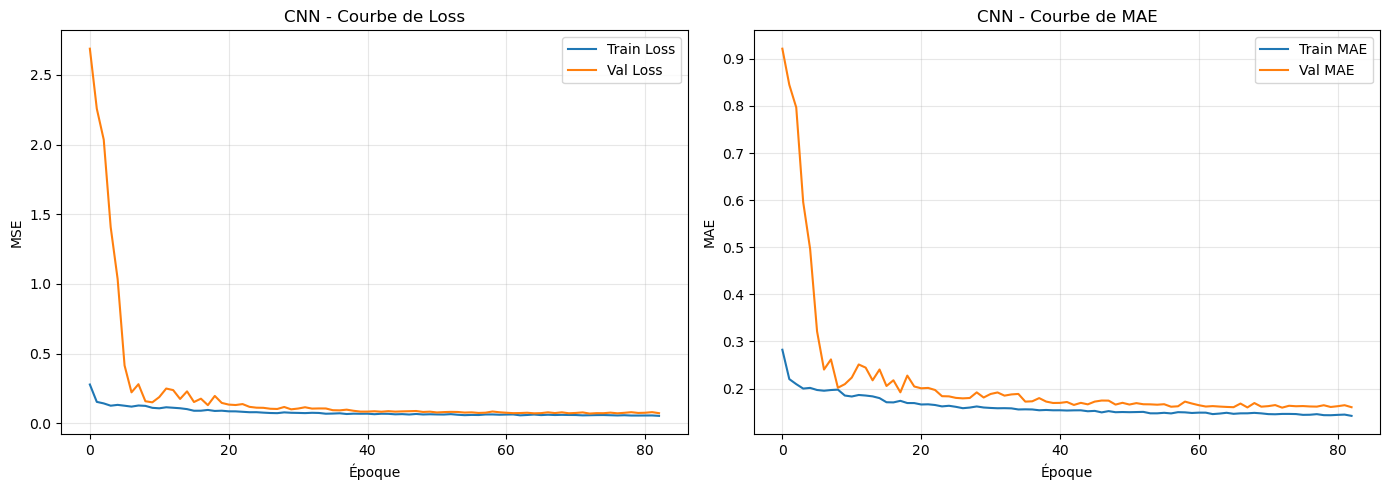

In [22]:
# Entraînement CNN
callbacks_cnn = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

print("🔄 Entraînement CNN...")
historique_cnn = modele_cnn.fit(
    X_train_cnn, y_train_1d,
    validation_data=(X_train_cnn[-200:], y_train_1d[-200:]),
    epochs=100,
    batch_size=64,
    callbacks=callbacks_cnn,
    verbose=1
)

# Courbes d'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(historique_cnn.history['loss'], label='Train Loss')
axes[0].plot(historique_cnn.history['val_loss'], label='Val Loss')
axes[0].set_title('CNN - Courbe de Loss')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(historique_cnn.history['mae'], label='Train MAE')
axes[1].plot(historique_cnn.history['val_mae'], label='Val MAE')
axes[1].set_title('CNN - Courbe de MAE')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_training.png', dpi=150, bbox_inches='tight')
plt.show()

54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step

📊 [CNN] Résultats sur le jeu de TEST (20%) :
   MAE  = 1.2315 km/h
   RMSE = 2.3569 km/h
   MAPE = 2.05 %


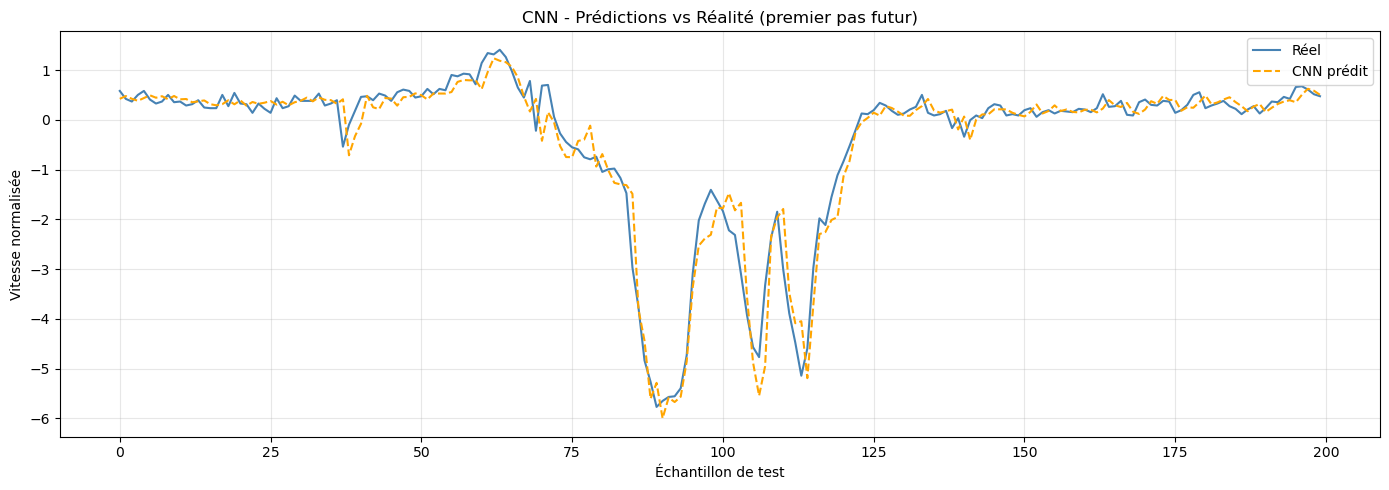

In [23]:
# Évaluation CNN
pred_cnn = modele_cnn.predict(X_test_cnn)
res_cnn = evaluer(y_test_1d.flatten(), pred_cnn.flatten(), 'CNN', scaler_1d)
resultats_globaux.append(res_cnn)

# Visualisation
plt.figure(figsize=(14, 5))
n_show = min(200, len(y_test_1d))
plt.plot(y_test_1d[:n_show, 0], label='Réel', color='steelblue', linewidth=1.5)
plt.plot(pred_cnn[:n_show, 0], label='CNN prédit', color='orange', 
         linestyle='--', linewidth=1.5)
plt.title('CNN - Prédictions vs Réalité (premier pas futur)')
plt.xlabel('Échantillon de test')
plt.ylabel('Vitesse normalisée')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler as SS

# ============================================================
# SVM — Split 80 % train / 20 % test
# ============================================================
# Le SVM prédit 1 pas à la fois → on crée N_PAS_SORTIE modèles
# Entrée  : vecteur de 12 valeurs (1 heure de passé)
# Sortie  : 1 valeur (un pas de 5 min dans le futur)
# ============================================================

print("🔄 Entraînement SVM (SVR kernel=rbf) — Split 80/20")
print(f"   Train : {X_train_1d.shape[0]} échantillons")
print(f"   Test  : {X_test_1d.shape[0]}  échantillons")
print("   (Patience : SVR peut être lent sur ~7000 échantillons)")

# Un modèle SVR par pas de sortie
modeles_svm = []
for pas in range(N_PAS_SORTIE):
    svr = make_pipeline(
        SS(),                          # re-normalisation interne
        SVR(kernel='rbf',
            C=10,                      # marge souple
            epsilon=0.05,              # tube ε
            gamma='scale',             # noyau automatique
            cache_size=500)            # accélère le calcul
    )
    svr.fit(X_train_1d, y_train_1d[:, pas])
    modeles_svm.append(svr)
    print(f"   ✓ SVR pas +{(pas+1)*5} min entraîné")

print("\n✅ SVM entraîné")

🔄 Entraînement SVM (SVR kernel=rbf) — Split 80/20
   Train : 6900 échantillons
   Test  : 1726  échantillons
   (Patience : SVR peut être lent sur ~7000 échantillons)
   ✓ SVR pas +5 min entraîné
   ✓ SVR pas +10 min entraîné
   ✓ SVR pas +15 min entraîné

✅ SVM entraîné



📊 [SVM] Résultats sur le jeu de TEST (20%) :
   MAE  = 1.2414 km/h
   RMSE = 2.5568 km/h
   MAPE = 2.08 %


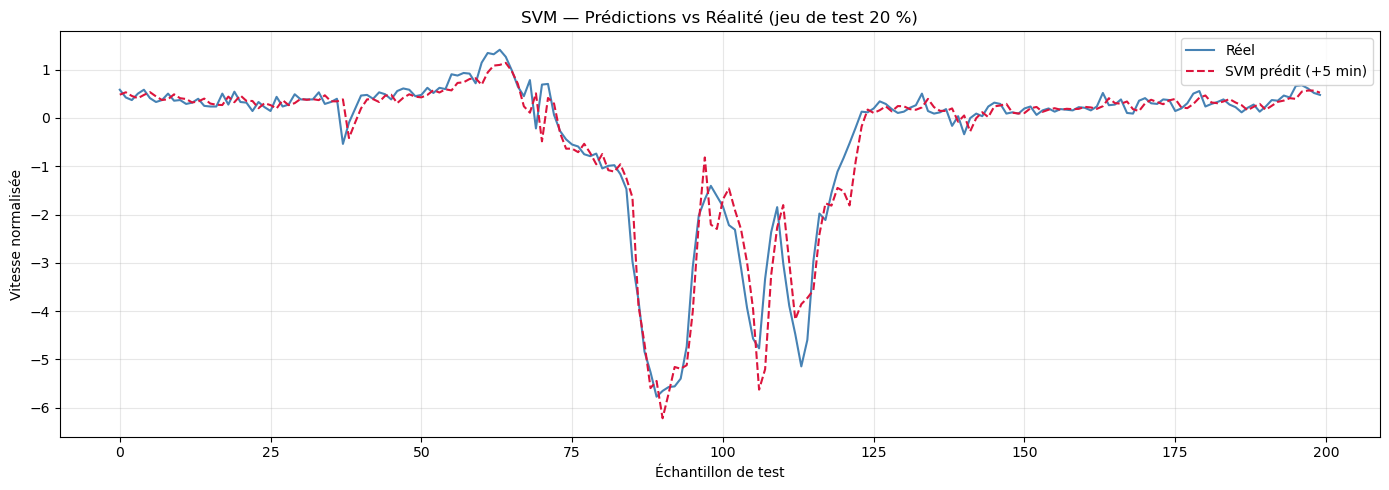

In [25]:
# Prédiction SVM sur le jeu de TEST (20 %)
pred_svm = np.column_stack([
    modeles_svm[pas].predict(X_test_1d)
    for pas in range(N_PAS_SORTIE)
])  # (N_test, N_PAS_SORTIE)

res_svm = evaluer(y_test_1d.flatten(), pred_svm.flatten(), 'SVM', scaler_1d)
resultats_globaux.append(res_svm)

# Visualisation
plt.figure(figsize=(14, 5))
n_show = min(200, len(y_test_1d))
plt.plot(y_test_1d[:n_show, 0], label='Réel', color='steelblue', linewidth=1.5)
plt.plot(pred_svm[:n_show, 0],  label='SVM prédit (+5 min)', color='crimson',
         linestyle='--', linewidth=1.5)
plt.title('SVM — Prédictions vs Réalité (jeu de test 20 %)')
plt.xlabel('Échantillon de test')
plt.ylabel('Vitesse normalisée')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('svm_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Reshape pour LSTM : (N, timesteps, features)
X_train_lstm = X_train_1d.reshape(-1, N_PAS_ENTREE, 1)
X_test_lstm  = X_test_1d.reshape(-1, N_PAS_ENTREE, 1)

# ============================================================
# ARCHITECTURE LSTM
# ============================================================

def creer_modele_lstm(n_entree, n_sortie):
    inputs = keras.Input(shape=(n_entree, 1), name='input_serie')
    
    # Couches LSTM empilées
    x = layers.LSTM(128, return_sequences=True, name='lstm1')(inputs)
    x = layers.Dropout(0.2)(x)
    
    x = layers.LSTM(64, return_sequences=True, name='lstm2')(x)
    x = layers.Dropout(0.2)(x)
    
    x = layers.LSTM(32, return_sequences=False, name='lstm3')(x)
    x = layers.Dropout(0.2)(x)
    
    # Tête de régression
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(n_sortie, name='output')(x)
    
    model = keras.Model(inputs, outputs, name='LSTM_Trafic')
    return model

modele_lstm = creer_modele_lstm(N_PAS_ENTREE, N_PAS_SORTIE)
modele_lstm.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)
modele_lstm.summary()

Model: "LSTM_Trafic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_serie (InputLayer)             │ (None, 12, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm1 (LSTM)                         │ (None, 12, 128)             │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 12, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm2 (LSTM)                         │ (None, 12, 64)              │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 12, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm3 (LSTM)                         │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 129,539 (506.01 KB)

 Trainable params: 129,539 (506.01 KB)

 Non-trainable params: 0 (0.00 B)

🔄 Entraînement LSTM...
Epoch 1/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 38s 108ms/step - loss: 0.3785 - mae: 0.3145 - val_loss: 0.4435 - val_mae: 0.3450 - learning_rate: 0.0010
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 19s 88ms/step - loss: 0.1854 - mae: 0.2304 - val_loss: 0.3528 - val_mae: 0.3032 - learning_rate: 0.0010
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 108ms/step - loss: 0.1517 - mae: 0.2100 - val_loss: 0.2142 - val_mae: 0.2533 - learning_rate: 0.0010
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 18s 81ms/step - loss: 0.1237 - mae: 0.1930 - val_loss: 0.2250 - val_mae: 0.2452 - learning_rate: 0.0010
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - loss: 0.1125 - mae: 0.1845 - val_loss: 0.1848 - val_mae: 0.2302 - learning_rate: 0.0010
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - loss: 0.1115 - mae: 0.1821 - val_loss: 0.1869 - val_mae: 0.2316 - learning_rate: 0.0010
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - loss: 0.1074 - mae: 0.1792 - val_loss: 0.2077 - va

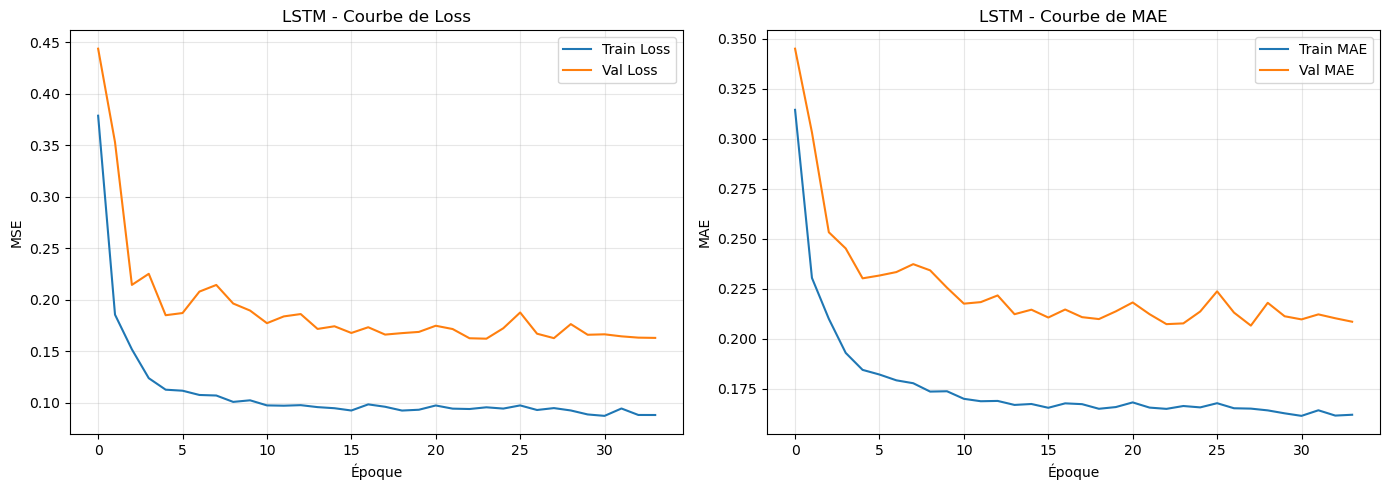

In [27]:
# Entraînement LSTM
callbacks_lstm = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

print("🔄 Entraînement LSTM...")
historique_lstm = modele_lstm.fit(
    X_train_lstm, y_train_1d,
    validation_data=(X_train_lstm[-200:], y_train_1d[-200:]),
    epochs=100,
    batch_size=64,
    callbacks=callbacks_lstm,
    verbose=1
)

# Courbes d'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(historique_lstm.history['loss'], label='Train Loss')
axes[0].plot(historique_lstm.history['val_loss'], label='Val Loss')
axes[0].set_title('LSTM - Courbe de Loss')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(historique_lstm.history['mae'], label='Train MAE')
axes[1].plot(historique_lstm.history['val_mae'], label='Val MAE')
axes[1].set_title('LSTM - Courbe de MAE')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()

54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step

📊 [LSTM] Résultats sur le jeu de TEST (20%) :
   MAE  = 1.1739 km/h
   RMSE = 2.1970 km/h
   MAPE = 1.95 %


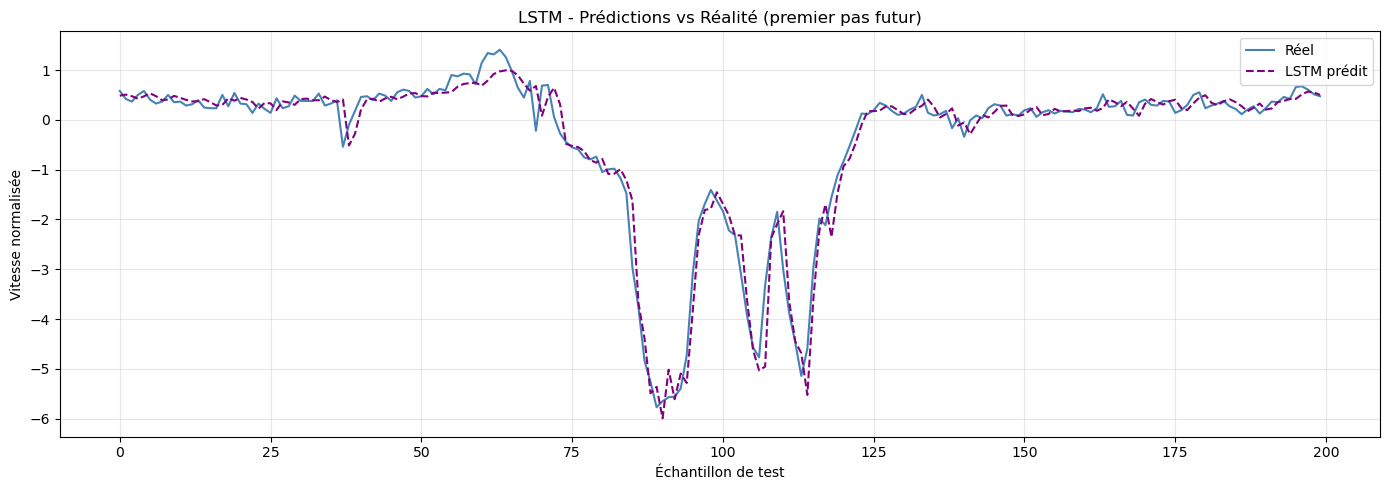

In [28]:
# Évaluation LSTM
pred_lstm = modele_lstm.predict(X_test_lstm)
res_lstm = evaluer(y_test_1d.flatten(), pred_lstm.flatten(), 'LSTM', scaler_1d)
resultats_globaux.append(res_lstm)

# Visualisation
plt.figure(figsize=(14, 5))
n_show = min(200, len(y_test_1d))
plt.plot(y_test_1d[:n_show, 0], label='Réel', color='steelblue', linewidth=1.5)
plt.plot(pred_lstm[:n_show, 0], label='LSTM prédit', color='purple', 
         linestyle='--', linewidth=1.5)
plt.title('LSTM - Prédictions vs Réalité (premier pas futur)')
plt.xlabel('Échantillon de test')
plt.ylabel('Vitesse normalisée')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Désinstaller
!pip uninstall torch torchvision torchaudio -y

# Réinstaller la version stable CPU
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Found existing installation: torch 2.10.0+cpu
Uninstalling torch-2.10.0+cpu:
  Successfully uninstalled torch-2.10.0+cpu
Found existing installation: torchvision 0.25.0+cpu
Uninstalling torchvision-0.25.0+cpu:
  Successfully uninstalled torchvision-0.25.0+cpu
Found existing installation: torchaudio 2.10.0+cpu
Uninstalling torchaudio-2.10.0+cpu:
  Successfully uninstalled torchaudio-2.10.0+cpu
Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download.pytorch.org/whl/cpu/torch-2.10.0%2Bcpu-cp313-cp313-win_amd64.whl.metadata (29 kB)
  Using cached https://download.pytorch.org/whl/cpu/torchvision-0.25.0%2Bcpu-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached https://download.pytorch.org/whl/cpu/torchaudio-2.10.0%2Bcpu-cp313-cp313-win_amd64.whl.metadata (7.0 kB)
Using cached https://download.pytorch.org/whl/cpu/torch-2.10.0%2Bcpu-cp313-cp313-win_amd64.whl (113.7 MB)
Using cached https://download.pytorch.org/whl/cpu/torchvision-0.25.0%2Bcpu-cp313-cp313

In [30]:
import torch
print(f"✅ PyTorch version : {torch.__version__}")
print(f"   CUDA disponible : {torch.cuda.is_available()}")

✅ PyTorch version : 2.10.0+cpu
   CUDA disponible : False


In [32]:
import pickle

# ── CORRECTION : ajouter encoding='latin1' ──────────────────
with open('../dataset/adj_mx_bay.pkl', 'rb') as f:
    sensor_ids, sensor_id_to_ind, adj_mx = pickle.load(f, encoding='latin1')

print(f"✅ Matrice d'adjacence chargée : {adj_mx.shape}")
print(f"   Capteurs : {len(sensor_ids)}")

✅ Matrice d'adjacence chargée : (325, 325)
   Capteurs : 325


✅ Matrice d'adjacence chargée : (325, 325)
   Capteurs : 325


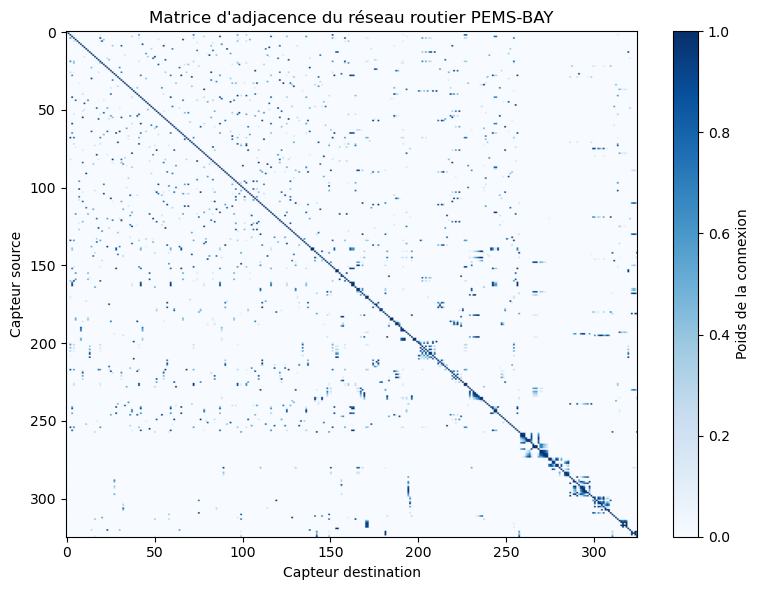

Séquences GCN : X=(8626, 12, 325), y=(8626, 3, 325)
   Train : torch.Size([6900, 12, 325])  (80%)
   Val   : torch.Size([200, 12, 325])   (early stopping uniquement)
   Test  : torch.Size([1726, 12, 325])  (20%)
✅ Matrice d'adjacence normalisée : torch.Size([325, 325])
Device : cpu
Paramètres : 2,051
🔄 Entraînement GCN...
   Époque [ 10/50] | Train: 0.409682 | Val: 0.848785
   Époque [ 20/50] | Train: 0.402809 | Val: 0.825368
   Époque [ 30/50] | Train: 0.398893 | Val: 0.805389
   Époque [ 40/50] | Train: 0.394735 | Val: 0.788870
   Époque [ 50/50] | Train: 0.391507 | Val: 0.775107
✅ Meilleur modèle restauré (val_loss = 0.775107)


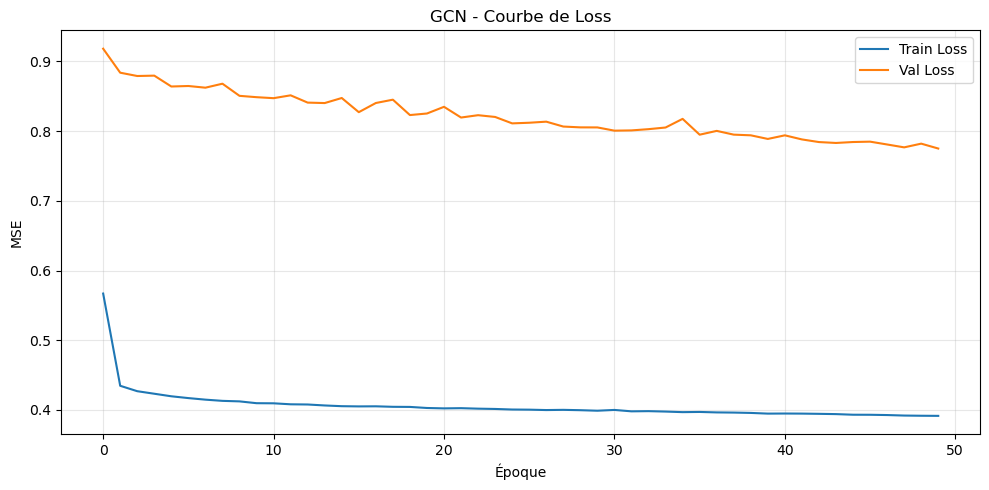


📊 [GCN] Résultats sur le jeu de test :
   MAE  = 2.7282 km/h
   RMSE = 4.7804 km/h
   MAPE = 5.42 %


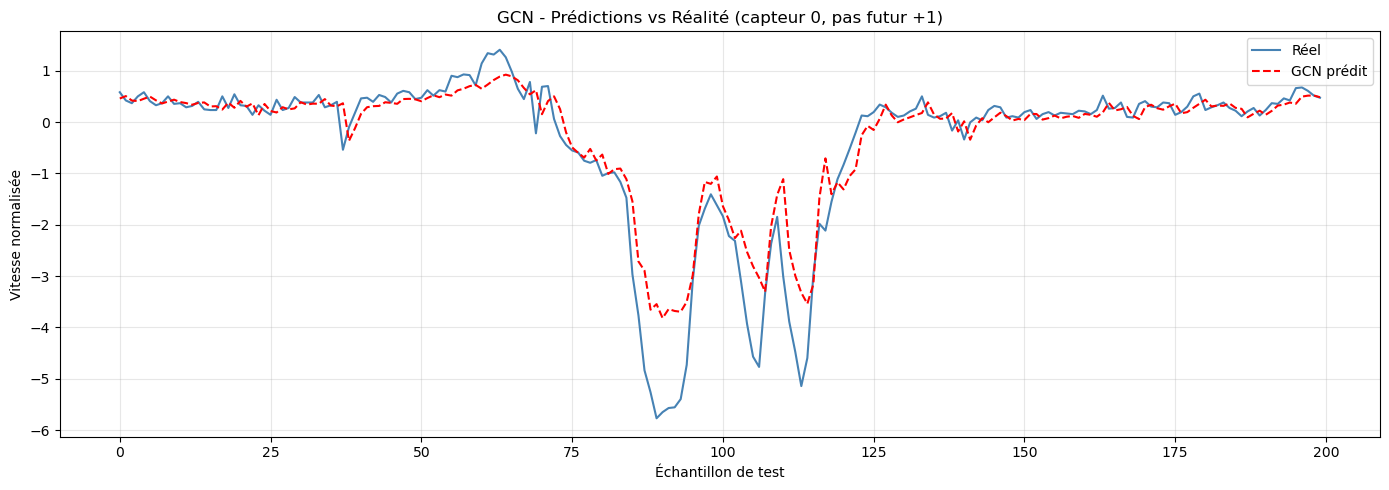

In [34]:
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# ============================================================
# CHARGER LA MATRICE D'ADJACENCE  ← encoding='latin1' ajouté
# ============================================================
with open('../dataset/adj_mx_bay.pkl', 'rb') as f:
    sensor_ids, sensor_id_to_ind, adj_mx = pickle.load(f, encoding='latin1')

print(f"✅ Matrice d'adjacence chargée : {adj_mx.shape}")
print(f"   Capteurs : {len(sensor_ids)}")

# Visualisation
plt.figure(figsize=(8, 6))
plt.imshow(adj_mx, cmap='Blues', aspect='auto')
plt.colorbar(label='Poids de la connexion')
plt.title("Matrice d'adjacence du réseau routier PEMS-BAY")
plt.xlabel('Capteur destination')
plt.ylabel('Capteur source')
plt.tight_layout()
plt.savefig('adj_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# PRÉPARATION DES DONNÉES POUR GCN
# ============================================================
N_CAPTEURS     = data_mois.shape[1]   # 325
scaler_gcn     = StandardScaler()
data_mois_norm = scaler_gcn.fit_transform(data_mois)   # (8640, 325)

def creer_sequences_gcn(data, n_entree, n_sortie):
    X, y = [], []
    for i in range(len(data) - n_entree - n_sortie + 1):
        X.append(data[i : i + n_entree])
        y.append(data[i + n_entree : i + n_entree + n_sortie])
    return np.array(X), np.array(y)

X_gcn, y_gcn = creer_sequences_gcn(data_mois_norm, N_PAS_ENTREE, N_PAS_SORTIE)
print(f"Séquences GCN : X={X_gcn.shape}, y={y_gcn.shape}")

n       = len(X_gcn)
n_train = int(n * TRAIN_RATIO)          # 80%

# ── Split 80% train / 20% test ──────────────────────────────
X_train_gcn = torch.FloatTensor(X_gcn[:n_train])
y_train_gcn = torch.FloatTensor(y_gcn[:n_train])

X_val_gcn   = torch.FloatTensor(X_gcn[n_train-200 : n_train])  # 200 échantillons pour early stopping
y_val_gcn   = torch.FloatTensor(y_gcn[n_train-200 : n_train])

X_test_gcn  = torch.FloatTensor(X_gcn[n_train:])               # 20% test officiel
y_test_gcn  = torch.FloatTensor(y_gcn[n_train:])

print(f"   Train : {X_train_gcn.shape}  (80%)")
print(f"   Val   : {X_val_gcn.shape}   (early stopping uniquement)")
print(f"   Test  : {X_test_gcn.shape}  (20%)")
# Normalisation Laplacienne : D^(-1/2) A D^(-1/2)
adj_tensor    = torch.FloatTensor(adj_mx)
deg           = adj_tensor.sum(dim=1)
deg_inv_sqrt  = torch.diag(deg.pow(-0.5))
deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0
adj_norm      = deg_inv_sqrt @ adj_tensor @ deg_inv_sqrt
print(f"✅ Matrice d'adjacence normalisée : {adj_norm.shape}")

# ============================================================
# ARCHITECTURE GCN (inchangée)
# ============================================================
class CoucheGCN(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.poids = nn.Linear(in_features, out_features)

    def forward(self, x, adj):
        x_agg = torch.bmm(adj.unsqueeze(0).expand(x.size(0), -1, -1), x)
        return F.relu(self.poids(x_agg))

class ModeleGCN(nn.Module):
    def __init__(self, n_capteurs, n_entree, n_sortie, dim_cache=32):
        super().__init__()
        self.gcn1    = CoucheGCN(n_entree,      dim_cache)
        self.gcn2    = CoucheGCN(dim_cache,      dim_cache)
        self.gcn3    = CoucheGCN(dim_cache,      dim_cache // 2)
        self.fc      = nn.Linear(dim_cache // 2, n_sortie)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x, adj):
        x = x.permute(0, 2, 1)          # (batch, n_capteurs, n_entree)
        x = self.dropout(self.gcn1(x, adj))
        x = self.dropout(self.gcn2(x, adj))
        x = self.gcn3(x, adj)
        out = self.fc(x)                 # (batch, n_capteurs, n_sortie)
        return out.permute(0, 2, 1)      # (batch, n_sortie, n_capteurs)

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

modele_gcn = ModeleGCN(N_CAPTEURS, N_PAS_ENTREE, N_PAS_SORTIE, dim_cache=32).to(device)
print(f"Paramètres : {sum(p.numel() for p in modele_gcn.parameters()):,}")

# ============================================================
# ENTRAÎNEMENT GCN
# ============================================================
optimiseur_gcn     = torch.optim.Adam(modele_gcn.parameters(), lr=1e-3)
scheduler_gcn      = torch.optim.lr_scheduler.ReduceLROnPlateau(
                         optimiseur_gcn, factor=0.5, patience=5, min_lr=1e-6)
critere_gcn        = nn.MSELoss()
adj_norm_device    = adj_norm.to(device)

N_EPOCHS           = 50
BATCH_SIZE         = 32
meilleure_val_loss = float('inf')
train_losses, val_losses = [], []

loader_train = DataLoader(TensorDataset(X_train_gcn, y_train_gcn),
                          batch_size=BATCH_SIZE, shuffle=True)

print("🔄 Entraînement GCN...")
for epoch in range(N_EPOCHS):
    modele_gcn.train()
    loss_train_ep = 0
    for X_batch, y_batch in loader_train:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimiseur_gcn.zero_grad()
        pred = modele_gcn(X_batch, adj_norm_device)
        loss = critere_gcn(pred, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(modele_gcn.parameters(), 1.0)
        optimiseur_gcn.step()
        loss_train_ep += loss.item()
    loss_train_ep /= len(loader_train)

    modele_gcn.eval()
    with torch.no_grad():
        pred_val = modele_gcn(X_val_gcn.to(device), adj_norm_device)
        loss_val = critere_gcn(pred_val, y_val_gcn.to(device)).item()

    scheduler_gcn.step(loss_val)
    train_losses.append(loss_train_ep)
    val_losses.append(loss_val)

    if loss_val < meilleure_val_loss:
        meilleure_val_loss = loss_val
        torch.save(modele_gcn.state_dict(), 'meilleur_gcn.pth')

    if (epoch + 1) % 10 == 0:
        print(f"   Époque [{epoch+1:3d}/{N_EPOCHS}] "
              f"| Train: {loss_train_ep:.6f} | Val: {loss_val:.6f}")

# ← weights_only=False ajouté
modele_gcn.load_state_dict(torch.load('meilleur_gcn.pth', weights_only=False))
print(f"✅ Meilleur modèle restauré (val_loss = {meilleure_val_loss:.6f})")

# Courbes d'apprentissage
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.title('GCN - Courbe de Loss')
plt.xlabel('Époque'); plt.ylabel('MSE')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gcn_training.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# ÉVALUATION GCN
# ============================================================
modele_gcn.eval()
with torch.no_grad():
    pred_gcn = modele_gcn(X_test_gcn.to(device), adj_norm_device).cpu().numpy()

y_test_gcn_np = y_test_gcn.numpy()

# Capteur 0 pour comparaison équitable avec ARIMA/CNN/LSTM
pred_gcn_cap0   = pred_gcn[:, 0, :].flatten()
y_test_gcn_cap0 = y_test_gcn_np[:, 0, :].flatten()

# ── Dénormalisation manuelle capteur 0 ──────────────────────
mean_cap0  = scaler_gcn.mean_[0]
scale_cap0 = scaler_gcn.scale_[0]

y_true_denorm = y_test_gcn_cap0 * scale_cap0 + mean_cap0
y_pred_denorm = pred_gcn_cap0   * scale_cap0 + mean_cap0

mae  = mean_absolute_error(y_true_denorm, y_pred_denorm)
rmse = np.sqrt(mean_squared_error(y_true_denorm, y_pred_denorm))
mask = y_true_denorm != 0
mape = np.mean(np.abs((y_true_denorm[mask] - y_pred_denorm[mask])
                       / y_true_denorm[mask])) * 100

print(f"\n📊 [GCN] Résultats sur le jeu de test :")
print(f"   MAE  = {mae:.4f} km/h")
print(f"   RMSE = {rmse:.4f} km/h")
print(f"   MAPE = {mape:.2f} %")

res_gcn = {'modele': 'GCN', 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}
resultats_globaux.append(res_gcn)

# Visualisation prédictions
n_show = min(200, len(y_test_gcn_np))
plt.figure(figsize=(14, 5))
plt.plot(y_test_gcn_np[:n_show, 0, 0], label='Réel',       color='steelblue', lw=1.5)
plt.plot(pred_gcn[:n_show, 0, 0],      label='GCN prédit', color='red', ls='--', lw=1.5)
plt.title('GCN - Prédictions vs Réalité (capteur 0, pas futur +1)')
plt.xlabel('Échantillon de test'); plt.ylabel('Vitesse normalisée')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gcn_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# Tableau comparatif
df_resultats = pd.DataFrame(resultats_globaux)
df_resultats = df_resultats.set_index('modele')
df_resultats = df_resultats.round(4)

print("\n" + "="*50)
print("🏆 COMPARAISON DES MODÈLES")
print("="*50)
print(df_resultats.to_string())
print("="*50)
print(f"\n🥇 Meilleur MAE  : {df_resultats['MAE'].idxmin()}  ({df_resultats['MAE'].min():.4f})")
print(f"🥇 Meilleur RMSE : {df_resultats['RMSE'].idxmin()} ({df_resultats['RMSE'].min():.4f})")
print(f"🥇 Meilleur MAPE : {df_resultats['MAPE'].idxmin()} ({df_resultats['MAPE'].min():.2f}%)")


🏆 COMPARAISON DES MODÈLES
           MAE    RMSE    MAPE
modele                        
ARIMA   2.5733  4.6568  5.0762
Kalman  1.3740  2.7446  2.3817
CNN     1.2315  2.3569  2.0466
SVM     1.2414  2.5568  2.0762
LSTM    1.1739  2.1970  1.9517
GCN     2.7282  4.7804  5.4187

🥇 Meilleur MAE  : LSTM  (1.1739)
🥇 Meilleur RMSE : LSTM (2.1970)
🥇 Meilleur MAPE : LSTM (1.95%)



🏆 COMPARAISON DES MODÈLES
           MAE    RMSE    MAPE
modele                        
ARIMA   2.5733  4.6568  5.0762
Kalman  1.3740  2.7446  2.3817
CNN     1.2315  2.3569  2.0466
SVM     1.2414  2.5568  2.0762
LSTM    1.1739  2.1970  1.9517
GCN     2.7282  4.7804  5.4187

🥇 Meilleur MAE  : LSTM  (1.1739)
🥇 Meilleur RMSE : LSTM (2.1970)
🥇 Meilleur MAPE : LSTM (1.95%)


C:\Users\HP\AppData\Local\Temp\ipykernel_12116\2458242433.py:41: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_12116\2458242433.py:42: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('comparaison_modeles.png', dpi=150, bbox_inches='tight')
C:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


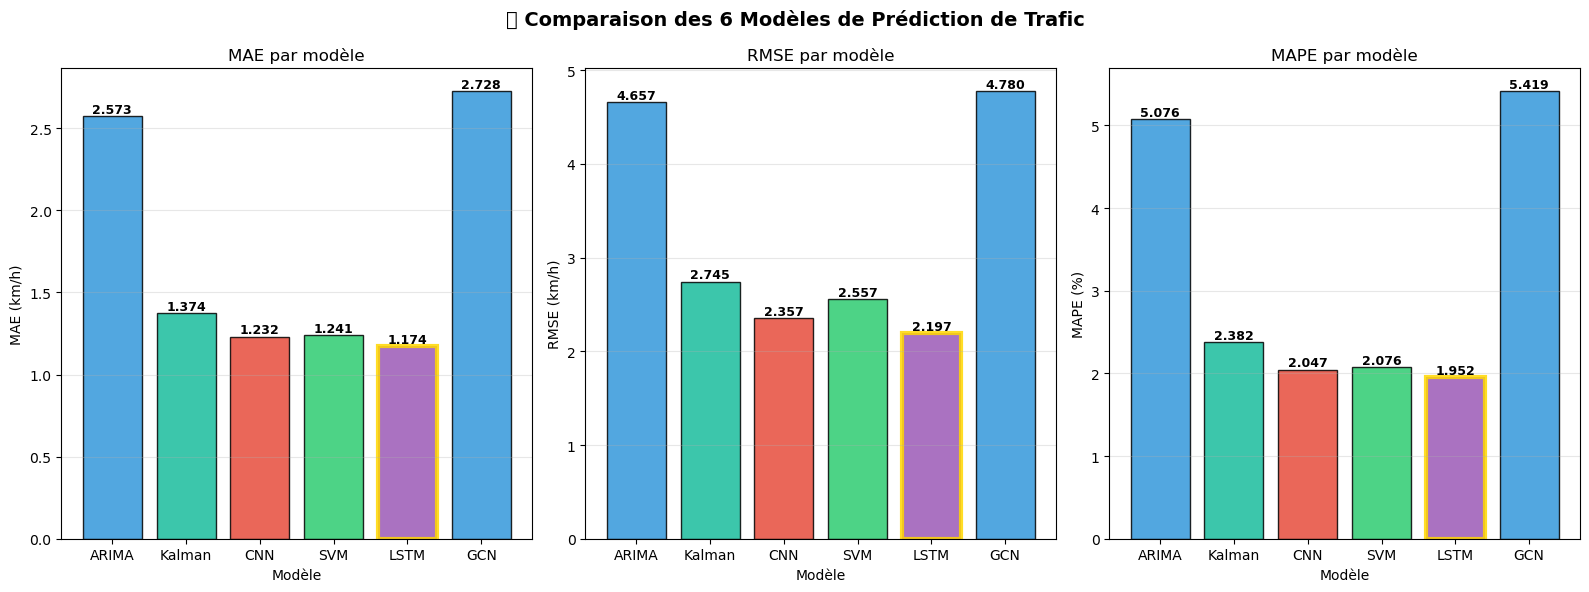

✅ Figure sauvegardée : comparaison_modeles.png


In [36]:
# Graphique comparatif (6 modèles)
df_resultats = pd.DataFrame(resultats_globaux)
df_resultats = df_resultats.set_index('modele')
df_resultats = df_resultats.round(4)

print("\n" + "="*55)
print("🏆 COMPARAISON DES MODÈLES")
print("="*55)
print(df_resultats.to_string())
print("="*55)
print(f"\n🥇 Meilleur MAE  : {df_resultats['MAE'].idxmin()}  ({df_resultats['MAE'].min():.4f})")
print(f"🥇 Meilleur RMSE : {df_resultats['RMSE'].idxmin()} ({df_resultats['RMSE'].min():.4f})")
print(f"🥇 Meilleur MAPE : {df_resultats['MAPE'].idxmin()} ({df_resultats['MAPE'].min():.2f}%)")

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('🏆 Comparaison des 6 Modèles de Prédiction de Trafic',
             fontsize=14, fontweight='bold')

couleurs = ['#3498db', '#1abc9c', '#e74c3c', '#2ecc71', '#9b59b6']
modeles  = df_resultats.index.tolist()

metriques = [('MAE', 'MAE (km/h)'), ('RMSE', 'RMSE (km/h)'), ('MAPE', 'MAPE (%)')]

for ax, (metrique, label) in zip(axes, metriques):
    valeurs = df_resultats[metrique].values
    bars = ax.bar(modeles, valeurs, color=couleurs[:len(modeles)],
                  edgecolor='black', alpha=0.85)
    ax.set_title(f'{metrique} par modèle')
    ax.set_ylabel(label)
    ax.set_xlabel('Modèle')
    ax.grid(True, axis='y', alpha=0.3)
    for bar, val in zip(bars, valeurs):
        ax.text(bar.get_x() + bar.get_width()/2.,
                bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom',
                fontweight='bold', fontsize=9)
    meilleur_idx = np.argmin(valeurs)
    bars[meilleur_idx].set_edgecolor('gold')
    bars[meilleur_idx].set_linewidth(3)

plt.tight_layout()
plt.savefig('comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : comparaison_modeles.png")


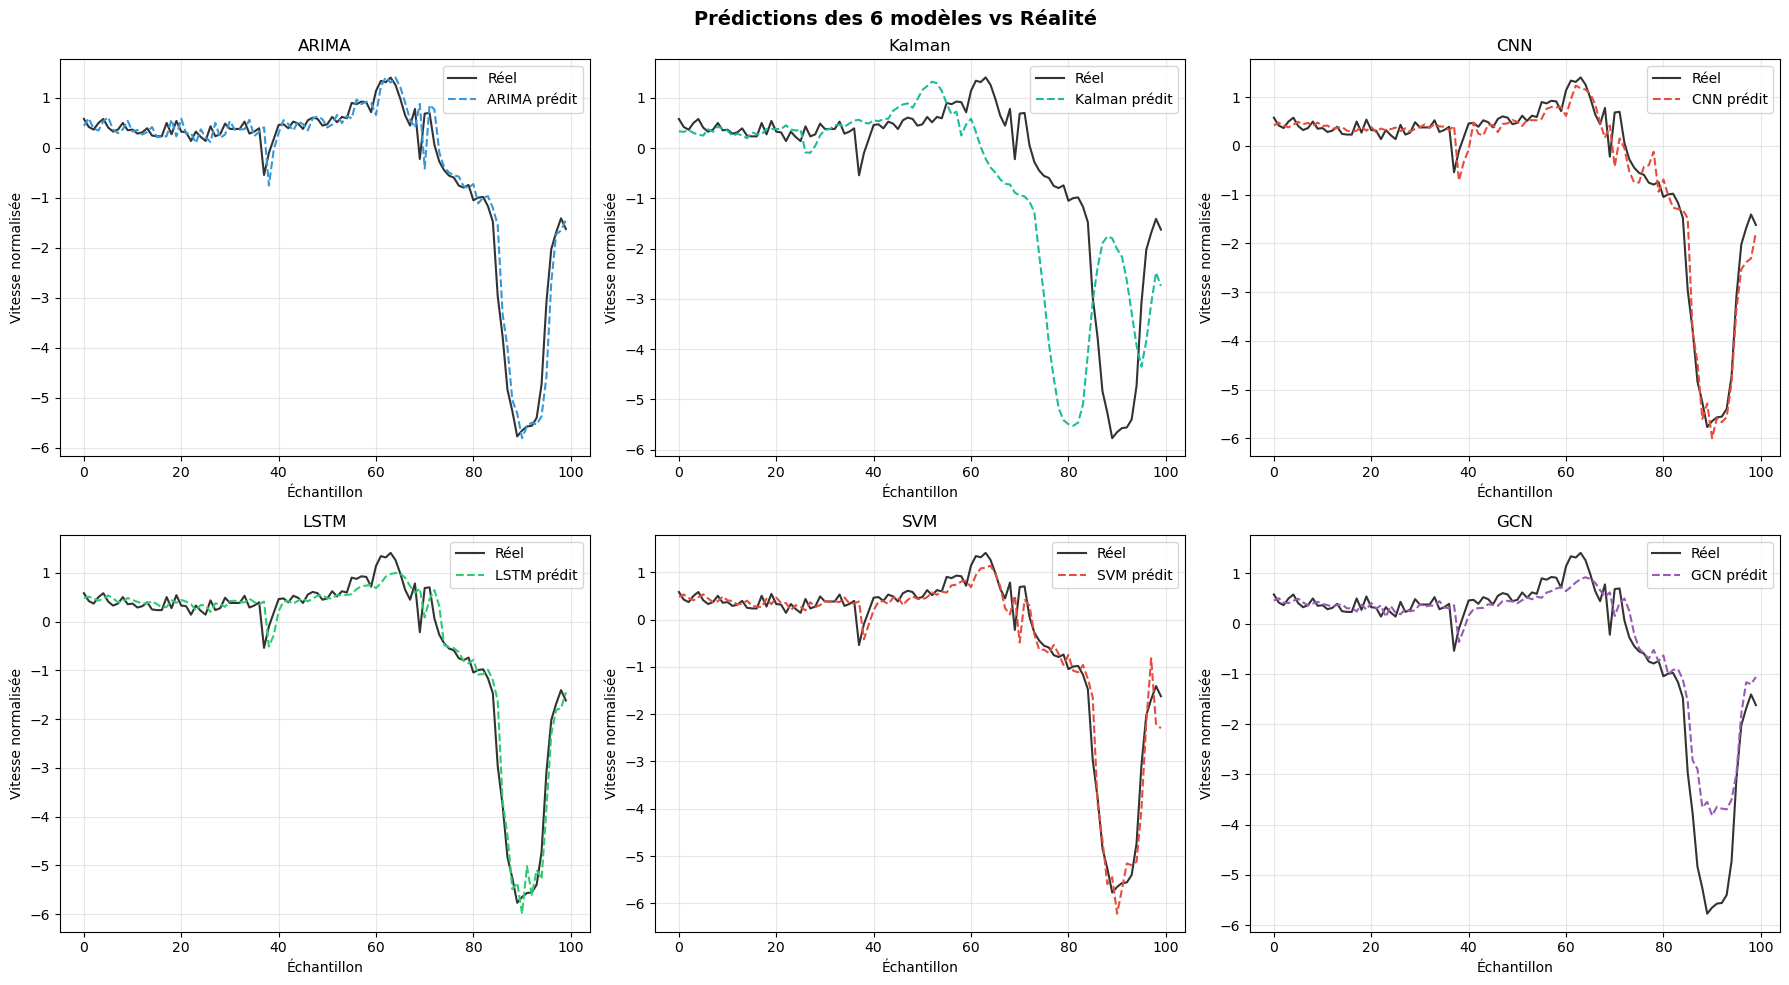

✅ Figure sauvegardée : comparaison_predictions.png


In [37]:
# Visualisation comparée des prédictions (6 modèles)
n_show = 100

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Prédictions des 6 modèles vs Réalité', fontsize=14, fontweight='bold')

# Réalité (normalisée) — capteur 0
reel = y_test_1d[:n_show, 0]

# Aligner les prédictions Kalman avec y_test_1d
# (les deux sont sur la même portion test, même longueur)
n_kalman = min(n_show, len(predictions_kalman))

configs = [
    (axes[0, 0], 'ARIMA',  predictions_arima[:n_show * N_PAS_SORTIE:N_PAS_SORTIE], '#3498db'),
    (axes[0, 1], 'Kalman', predictions_kalman[:n_kalman, 0],                        '#1abc9c'),
    (axes[0, 2], 'CNN',    pred_cnn[:n_show, 0],                                    '#e74c3c'),
    (axes[1, 0], 'LSTM',   pred_lstm[:n_show, 0],                                   '#2ecc71'),
    (axes[1, 1], 'SVM',    pred_svm[:n_show, 0],                                    '#e74c3c'),
    (axes[1, 2], 'GCN',     pred_gcn[:n_show, 0, 0],                                '#9b59b6'),
]

for ax, nom, pred, couleur in configs:
    if nom is None:
        ax.axis('off')
        continue
    ax.plot(reel, label='Réel', color='black', linewidth=1.5, alpha=0.8)
    min_len = min(len(reel), len(pred))
    ax.plot(pred[:min_len], label=f'{nom} prédit', color=couleur,
            linestyle='--', linewidth=1.5)
    ax.set_title(f'{nom}')
    ax.set_xlabel('Échantillon')
    ax.set_ylabel('Vitesse normalisée')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparaison_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : comparaison_predictions.png")
